# Epic of Sun - Desafio 1
Training the PSPNet model.
***

This jupyter notebook trains a PSPNet for sugarcane identification from satellite images.

It is divided in 5 parts:
* Loading libraries and data
* Separating the datasets in training and validation
* Build the model
* Train the model
* Evaluate the training

***

## Loading libraries and data

In [ ]:
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
#import random
import math

#import geopandas as gpd
#import rasterio
#from rasterio.features import rasterize

import json
#import joblib
from pathlib import Path
#import os

import tensorflow as tf
#from sklearn.model_selection import train_test_split
#import segmentation_models as sm
import keras
from keras import layers
from keras.models import Model
#from keras.models import load_model

#import keras_tuner as kt

2026-09-01 19:10:53.527753: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788300653.542748   38331 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788300653.547036   38331 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-01 19:10:53.562059: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Flags
flag_load_hyperparams = False
include_swir = False  # Set to True if you want to include SWIR bands

In [3]:
# Get the directory where THIS script is located
base_path = Path.cwd()
base_path = base_path.parent  # Move one level up to the project root

In [4]:
# Specify the paths to the mesh and image files
patches_path = base_path / "data" / "processed"

# Specify the path to the TFRecords directory
tfrecord_path = base_path / "data" / "tfrecords"

In [5]:
patch_index = pd.read_csv(patches_path / "patch_index.csv")

print(patch_index.head())
print(len(patch_index))

     scene  patch_id  row_start  col_start  \
0  scene01         0          0          0   
1  scene01         1          0         64   
2  scene01         2          0        128   
3  scene01         3          0        192   
4  scene01         4          0        256   

                                   x_patch_path  \
0  data/processed/scene01/images/patch_0000.npy   
1  data/processed/scene01/images/patch_0001.npy   
2  data/processed/scene01/images/patch_0002.npy   
3  data/processed/scene01/images/patch_0003.npy   
4  data/processed/scene01/images/patch_0004.npy   

                                  y_patch_path  sugarcane_pixels  
0  data/processed/scene01/masks/patch_0000.npy              8434  
1  data/processed/scene01/masks/patch_0001.npy             12836  
2  data/processed/scene01/masks/patch_0002.npy              9355  
3  data/processed/scene01/masks/patch_0003.npy              3983  
4  data/processed/scene01/masks/patch_0004.npy               805  
44890


## Selecting datasets in training and validation

In [6]:
# Load the best hyperparameters from the JSON file
if flag_load_hyperparams:
	json_path = base_path / "models" / "pspnet" / "pspnet_best_hyperparams.json"

	with open(json_path, "r") as f:
		saved_params = json.load(f)
	print("Loaded hyperparameters from JSON:")
	print(saved_params)
else:
	saved_params = {
		"init_filters": 32,
		"batch_size": 64,
		"lr": 0.00005
	}
	print("Hyperparameters not loaded from JSON. Using default values:")
	print(saved_params)

Hyperparameters not loaded from JSON. Using default values:
{'init_filters': 32, 'batch_size': 64, 'lr': 5e-05}


In [7]:
# Load the count JSON file
with open(tfrecord_path / "counts.json") as f:
    counts = json.load(f)

n_train, n_val, n_test = counts["train"], counts["val"], counts["test"]

In [8]:
# Functions to create TensorFlow datasets for training, validation, and testing

def _parse_example(example_proto, include_swir=include_swir):
    feature_description = {
        "x": tf.io.FixedLenFeature([], tf.string),
        "y": tf.io.FixedLenFeature([], tf.string),
        "scene": tf.io.FixedLenFeature([], tf.string),
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    x = tf.io.parse_tensor(parsed["x"], out_type=tf.float32)
    y = tf.io.parse_tensor(parsed["y"], out_type=tf.float32)

    # Set the shape of the tensors based on whether SWIR bands are included
    if include_swir:
        x.set_shape((128, 128, 6))  # 6 bands
    else:
        x.set_shape((128, 128, 4))  # 4 bands
    y.set_shape((128, 128, 1))

    """
     If the SWIR bands are include but you only want to use the first 4 bands 
     (Blue, Green, Red, NIR), you can slice the tensor as follows:
    # 1. Always set the shape to 6 because that is how it was saved in the TFRecord
    x.set_shape((128, 128, 6))  
    y.set_shape((128, 128, 1))
    # 2. Slice the tensor if you only want to use the first 4 bands (Blue, Green, Red, NIR)
    if not include_swir:
        x = x[..., :4]  # Keeps only channels 0, 1, 2, and 3"""

    scene = parsed["scene"]
    return x, y, scene

def _augment(x, y, scene):
    if tf.random.uniform(()) < 0.5:
        x = tf.image.flip_left_right(x); y = tf.image.flip_left_right(y)
    if tf.random.uniform(()) < 0.5:
        x = tf.image.flip_up_down(x); y = tf.image.flip_up_down(y)
    k = tf.random.uniform((), maxval=4, dtype=tf.int32)
    x = tf.image.rot90(x, k); y = tf.image.rot90(y, k)
    factor = tf.random.uniform((), 0.9, 1.1)
    x = tf.clip_by_value(x * factor, 0.0, 1.0)
    return x, y, scene

def _add_indices(x, y, scene, include_swir=include_swir):
    if include_swir:
        blue, green, red, nir, swir1, swir2 = x[..., 0], x[..., 1], x[..., 2], x[..., 3], x[..., 4], x[..., 5]
    else:
        blue, green, red, nir = x[..., 0], x[..., 1], x[..., 2], x[..., 3]
    eps = 1e-8
    ndvi = (nir - red) / (nir + red + eps)
    ndwi = (green - nir) / (green + nir + eps)
    evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + eps)
    if include_swir:
        x = tf.stack([blue, green, red, nir, swir1, swir2, ndvi, ndwi, evi], axis=-1)
    else:
        x = tf.stack([blue, green, red, nir, ndvi, ndwi, evi], axis=-1)

    return x, y, scene

def _drop_scene(x, y, scene):
    return x, y

def make_tfrecord_dataset(prefix, batch_size, num_patches, shuffle=True,
                           augment=True, compute_indices=True, keep_scene=False, include_swir=include_swir):
    file_pattern = str(tfrecord_path / f"{prefix}_*.tfrecord")
    files = tf.data.Dataset.list_files(file_pattern, shuffle=shuffle)

    ds = files.interleave(
        tf.data.TFRecordDataset,
        cycle_length=2,       # fewer simultaneously-open files = less seeking
        block_length=16,      # read 16 records sequentially from each file before switching
        num_parallel_calls=tf.data.AUTOTUNE
    )
    # Use this one line instead of the next one to avoid the error "ValueError: 
    # num_parallel_calls must be a tf.int32 scalar tensor or None."
    ds = ds.map(lambda x: _parse_example(x, include_swir=include_swir), num_parallel_calls=tf.data.AUTOTUNE)
    # Use this line to avoid overheading the CPU with too many parallel calls, 
    # which can lead to the error "ValueError: num_parallel_calls must be a 
    # tf.int32 scalar tensor or None."
    #ds = ds.map(_parse_example, num_parallel_calls=2)  # instead of AUTOTUNE

    if shuffle:
        ds = ds.shuffle(buffer_size=2000)
    if augment:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    if compute_indices:
        ds = ds.map(lambda x, y, scene: _add_indices(x, y, scene, include_swir=include_swir), num_parallel_calls=tf.data.AUTOTUNE)

    # Drop the scene string BEFORE batching, not after -- keeps the batched
    # element structure as plain (x, y), which is what model.fit() expects.
    # Do this before .batch() rather than after, since batching a dropped
    # scalar string alongside numeric tensors is exactly what caused the
    # XLA_GPU_JIT error you hit.
    if not keep_scene:
        ds = ds.map(_drop_scene, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)

    num_batches = math.ceil(num_patches / batch_size)
    ds = ds.apply(tf.data.experimental.assert_cardinality(num_batches))

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [9]:
# Create TensorFlow datasets for training, validation, and testing
# Only train and validation is going to be used in this notebook, so no test dataset is created.
train_ds = make_tfrecord_dataset("train", saved_params["batch_size"], n_train, shuffle=True, augment=True, include_swir=include_swir)
val_ds   = make_tfrecord_dataset("val",   saved_params["batch_size"], n_val,   shuffle=False, augment=True, include_swir=include_swir)
#test_ds  = make_tfrecord_dataset("test",  saved_params["batch_size"], n_test,  shuffle=False, augment=False, include_swir=include_swir)

I0000 00:00:1788300657.583759   38331 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


In [10]:
# Show the number of batches in training, validation, and testing sets
# Taken form the counts.json file, which is generated during the TFRecord creation process
print("Training batches:", n_train)
print("Validation batches:", n_val)
#print("Testing batches:", n_test)

Training batches: 26934
Validation batches: 8978


In [11]:
# Get a sample batch from the training generator to inspect its shape and data type
X_batch, y_batch = next(iter(train_ds))

print("Training batch shape:", X_batch.shape)
print("Training label shape:", y_batch.shape)
print("Training batch data type:", X_batch.dtype)
print("Training label data type:", y_batch.dtype)

2026-09-01 19:10:59.256525: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:370] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-09-01 19:11:09.255968: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 1080 of 2000
2026-09-01 19:11:18.743492: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


Training batch shape: (64, 128, 128, 7)
Training label shape: (64, 128, 128, 1)
Training batch data type: <dtype: 'float32'>
Training label data type: <dtype: 'float32'>


## Build the Model

In [12]:
# Loss functions

# Binary cross-entropy treats every pixel independently and doesn't "know" about overlap; 
# Dice loss directly optimizes for segmentation overlap, which is exactly what IoU measures, 
# and it tends to push recall up for the minority-in-that-image foreground class without 
# hurting precision much.

@tf.keras.utils.register_keras_serializable()
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

@tf.keras.utils.register_keras_serializable()
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

@tf.keras.utils.register_keras_serializable()
def combined_loss(alpha=0.5):
    """
    alpha: weight on BCE component. (1-alpha) weight on Dice.
    alpha=1.0 -> pure BCE (your original, precision-favoring setup)
    alpha=0.0 -> pure Dice (recall/overlap-favoring, likely what you just ran)
    alpha=0.5 -> balanced mix
    """
    def loss_fn(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        bce = tf.reduce_mean(bce)

        y_true_f = tf.reshape(y_true, [-1])
        y_pred_f = tf.reshape(y_pred, [-1])
        smooth = 1e-6
        intersection = tf.reduce_sum(y_true_f * y_pred_f)
        dice = 1 - (2. * intersection + smooth) / (
            tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
        )

        return alpha * bce + (1 - alpha) * dice
    return loss_fn

In [27]:
# =============================================================================
# 1. D-scSE block (the paper's core contribution)
#    sSE branch: spatial attention (which PIXELS matter)
#    cSE branch: channel attention (which CHANNELS matter)
#    Combined with learnable scalar weights alpha, beta (this is the "Dynamic" part)
# =============================================================================
def d_scse_block(x, name):
    filters = x.shape[-1]

    # --- sSE: spatial squeeze and excitation ---
    # 1x1 conv collapses all channels down to a single "spatial importance" map
    sse = layers.Conv2D(1, 1, padding="same", activation="sigmoid",
                         name=f"{name}_sse_conv")(x)
    sse_out = layers.Multiply(name=f"{name}_sse_scale")([x, sse])

    # --- cSE: channel squeeze and excitation ---
    # Paper uses BOTH global average pooling AND global max pooling, concatenated
    # (this differs from the original SE-Net, which only used avg pooling)
    avg_pool = layers.GlobalAveragePooling2D(name=f"{name}_cse_avgpool")(x)
    max_pool = layers.GlobalMaxPooling2D(name=f"{name}_cse_maxpool")(x)
    pooled = layers.Concatenate(name=f"{name}_cse_concat")([avg_pool, max_pool])

    reduction = max(filters // 16, 8)  # standard SE reduction ratio; assumption, paper doesn't give exact number
    cse = layers.Dense(reduction, activation="relu", name=f"{name}_cse_fc1")(pooled)
    cse = layers.Dense(filters, activation="sigmoid", name=f"{name}_cse_fc2")(cse)
    cse = layers.Reshape((1, 1, filters), name=f"{name}_cse_reshape")(cse)
    cse_out = layers.Multiply(name=f"{name}_cse_scale")([x, cse])

    # --- Dynamic weighting: learnable scalars alpha, beta combine the two branches ---
    # Implemented as a tiny custom layer since Keras has no built-in "learnable scalar."
    @keras.saving.register_keras_serializable()
    class DynamicWeight(layers.Layer):
        def build(self, input_shape):
            self.alpha = self.add_weight(name="alpha", shape=(), initializer="ones", trainable=True)
            self.beta = self.add_weight(name="beta", shape=(), initializer="ones", trainable=True)
        def call(self, inputs):
            sse_in, cse_in = inputs
            return self.alpha * sse_in + self.beta * cse_in

    return DynamicWeight(name=f"{name}_dynamic_combine")([sse_out, cse_out])


In [14]:
# =============================================================================
# 2. Modified ResNet34 backbone building blocks
# =============================================================================
def basic_residual_block(x, filters, stride=1, dilation=1, name=""):
    """Standard ResNet BasicBlock: two 3x3 convs + skip connection."""
    shortcut = x
    x = layers.Conv2D(filters, 3, strides=stride, padding="same",
                       dilation_rate=dilation, use_bias=False, name=f"{name}_conv1")(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_relu1")(x)

    x = layers.Conv2D(filters, 3, padding="same",
                       dilation_rate=dilation, use_bias=False, name=f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)

    # Project the shortcut if channels or spatial size changed
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same",
                                  use_bias=False, name=f"{name}_shortcut_conv")(shortcut)
        shortcut = layers.BatchNormalization(name=f"{name}_shortcut_bn")(shortcut)

    x = layers.Add(name=f"{name}_add")([x, shortcut])
    x = layers.Activation("relu", name=f"{name}_relu2")(x)
    return x

In [15]:
# Function to create a ResNet layer (a stack of basic blocks)
def resnet_layer(x, filters, n_blocks, stride=1, dilation=1, name=""):
    """A ResNet 'layer' = a stack of basic blocks. Only the first block downsamples."""
    x = basic_residual_block(x, filters, stride=stride, dilation=dilation, name=f"{name}_block1")
    for i in range(2, n_blocks + 1):
        x = basic_residual_block(x, filters, stride=1, dilation=dilation, name=f"{name}_block{i}")
    return x

In [16]:
# Function to build the modified ResNet34 backbone with D-scSE blocks
def modified_resnet34_backbone(inputs):
    """
    Standard ResNet34 layer counts: [3, 4, 6, 3] blocks at [64, 128, 256, 512] filters.
    Modification per the paper: layer3 and layer4 use DILATION instead of stride,
    so spatial resolution stops shrinking after layer2 (output stride = 8, not 32).
    D-scSE is applied after each of the 4 layers.

    Dilation rates (2 for layer3, 4 for layer4) follow the standard "dilated ResNet"
    convention used in PSPNet/DeepLab literature — the paper doesn't give exact
    numbers, so treat this as a documented assumption, not a verified detail.
    """
    # --- Stem ---
    x = layers.Conv2D(64, 7, strides=2, padding="same", use_bias=False, name="stem_conv")(inputs)
    x = layers.BatchNormalization(name="stem_bn")(x)
    x = layers.Activation("relu", name="stem_relu")(x)
    x = layers.MaxPooling2D(3, strides=2, padding="same", name="stem_pool")(x)

    # --- Layer 1: 3 blocks, 64 filters, stride 1 ---
    x = resnet_layer(x, 64, n_blocks=3, stride=1, dilation=1, name="layer1")
    x = d_scse_block(x, name="layer1_dscse")

    # --- Layer 2: 4 blocks, 128 filters, stride 2 (last normal downsample) ---
    x = resnet_layer(x, 128, n_blocks=4, stride=2, dilation=1, name="layer2")
    x = d_scse_block(x, name="layer2_dscse")

    # --- Layer 3: 6 blocks, 256 filters, DILATED (stride 1, dilation 2) ---
    x = resnet_layer(x, 256, n_blocks=6, stride=1, dilation=2, name="layer3")
    x = d_scse_block(x, name="layer3_dscse")

    # --- Layer 4: 3 blocks, 512 filters, DILATED (stride 1, dilation 4) ---
    x = resnet_layer(x, 512, n_blocks=3, stride=1, dilation=4, name="layer4")
    x = d_scse_block(x, name="layer4_dscse")

    return x  # feature map at 1/8 of input resolution

In [17]:
# =============================================================================
# 3. PSPNet decoder: pyramid pooling module + D-scSE + final convs
# =============================================================================
def pyramid_pooling_module(x, pool_sizes=(1, 2, 3, 6), filters=None):
    """
    Standard PSPNet bin sizes are (1, 2, 3, 6) — this IS a well-established
    convention from the original PSPNet paper (Zhao et al. 2017), not a guess
    specific to DSCA-PSPNet.
    """
    input_size = x.shape[1:3]  # (H, W)
    if filters is None:
        filters = x.shape[-1] // 4  # "reduce to C/4" as described in the paper

    pooled_branches = [x]  # keep the original feature map too (for concatenation later)
    for pool_size in pool_sizes:
        pooled = layers.AveragePooling2D(
            pool_size=(input_size[0] // pool_size, input_size[1] // pool_size),
            strides=(input_size[0] // pool_size, input_size[1] // pool_size),
            padding="same", name=f"ppm_pool_{pool_size}"
        )(x)
        pooled = layers.Conv2D(filters, 1, padding="same", use_bias=False,
                                name=f"ppm_conv_{pool_size}")(pooled)
        pooled = layers.BatchNormalization(name=f"ppm_bn_{pool_size}")(pooled)
        pooled = layers.Activation("relu", name=f"ppm_relu_{pool_size}")(pooled)
        pooled = layers.Resizing(input_size[0], input_size[1], interpolation="bilinear",
                                  name=f"ppm_upsample_{pool_size}")(pooled)
        pooled_branches.append(pooled)

    return layers.Concatenate(name="ppm_concat")(pooled_branches)


In [18]:
# Function to build the PSPNet decoder with D-scSE and final convolutions
def pspnet_decoder(backbone_features, target_size, num_classes=1):
    x = pyramid_pooling_module(backbone_features)
    x = d_scse_block(x, name="decoder_dscse")

    # Final convolutions (3x3 then 1x1, as described)
    x = layers.Conv2D(256, 3, padding="same", use_bias=False, name="decoder_conv3x3")(x)
    x = layers.BatchNormalization(name="decoder_bn")(x)
    x = layers.Activation("relu", name="decoder_relu")(x)
    x = layers.Dropout(0.1, name="decoder_dropout")(x)  # standard PSPNet practice before the final projection

    x = layers.Conv2D(num_classes, 1, name="decoder_logits")(x)
    x = layers.Resizing(target_size[0], target_size[1], interpolation="bilinear",
                         name="final_upsample")(x)
    outputs = layers.Activation("sigmoid", name="output_sigmoid")(x)
    return outputs

In [19]:
# =============================================================================
# 4. Full model builder — same signature style as your U-Net/FPN builders
# =============================================================================
def build_dsca_pspnet(input_shape=(128, 128, 7), lr=1e-3):
    inputs = layers.Input(input_shape)
    backbone_out = modified_resnet34_backbone(inputs)
    outputs = pspnet_decoder(backbone_out, target_size=input_shape[:2], num_classes=1)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4),
        loss=combined_loss(alpha=0.7),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(),
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall(),
        ]
    )
    return model

In [20]:
# Create the model with the best hyperparameters and the right input shape based on whether SWIR bands are included or not
if include_swir:
    input_shape = (128, 128, 9)
else:
    input_shape = (128, 128, 7)

model = build_dsca_pspnet(
    input_shape=input_shape,
    lr=saved_params["lr"],
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 7)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │     21,952 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 32, 32,    │          0 │ stem_relu[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_conv1 │ (None, 32, 32,    │     36,864 │ stem_pool[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_bn1   │ (None, 32, 32,    │        256 │ layer1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_relu1 │ (None, 32, 32,    │          0 │ layer1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_conv2 │ (None, 32, 32,    │     36,864 │ layer1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_bn2   │ (None, 32, 32,    │        256 │ layer1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_add   │ (None, 32, 32,    │          0 │ layer1_block1_bn… │
│ (Add)               │ 64)               │            │ stem_pool[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block1_relu2 │ (None, 32, 32,    │          0 │ layer1_block1_ad… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block2_conv1 │ (None, 32, 32,    │     36,864 │ layer1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block2_bn1   │ (None, 32, 32,    │        256 │ layer1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block2_relu1 │ (None, 32, 32,    │          0 │ layer1_block2_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block2_conv2 │ (None, 32, 32,    │     36,864 │ layer1_block2_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_block2_bn2   │ (None, 32, 32,    │        256 │ layer1_block2_co

 Total params: 24,205,776 (92.34 MB)

 Trainable params: 24,187,216 (92.27 MB)

 Non-trainable params: 18,560 (72.50 KB)

## Train the model

In [21]:
# Checkpoint callback to save the best model based on validation loss
model_path = base_path / "models" / "pspnet" / "pspnet_sugarcane.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    model_path,
    monitor="val_loss",
    save_best_only=True
)

In [22]:
# Checkpoint callback to stop training early if the validation loss does not improve for a certain number of epochs (patience)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [23]:
# Checkpoint callback to reduce learning rate when validation loss plateaus
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

In [24]:
# Train the model
print("Training a new model.")
history = model.fit(
	train_ds,
	validation_data=val_ds,
	epochs=100,
	callbacks=[checkpoint, early_stop, reduce_lr],
	verbose=1
)
history_dict = history.history
print("Training completed.")

Training a new model.
Epoch 1/100


2026-09-01 19:11:57.958154: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 780 of 2000
2026-09-01 19:12:07.985625: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 1648 of 2000
2026-09-01 19:12:13.481416: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
I0000 00:00:1788300734.190609   38453 service.cc:148] XLA service 0x7e33700274a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788300734.810961   38453 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-09-01 19:12:19.200503: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788300743.742101   38453 cuda_dnn.cc:529] Loaded cuDNN

420/421 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - binary_accuracy: 0.6348 - loss: 0.5752 - precision: 0.5483 - recall: 0.7257

2026-09-01 19:17:39.176434: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_8801', 36 bytes spill stores, 36 bytes spill loads

2026-09-01 19:17:40.918187: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_15823', 64 bytes spill stores, 64 bytes spill loads

2026-09-01 19:17:41.541656: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_15825', 68 bytes spill stores, 68 bytes spill loads

2026-09-01 19:18:07.103979: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_3', 60 bytes spill stores, 60 bytes spill loads



421/421 ━━━━━━━━━━━━━━━━━━━━ 503s 958ms/step - binary_accuracy: 0.7240 - loss: 0.4963 - precision: 0.6404 - recall: 0.7173 - val_binary_accuracy: 0.5643 - val_loss: 0.9437 - val_precision: 0.5252 - val_recall: 0.1723 - learning_rate: 5.0000e-05
Epoch 2/100


...

421/421 ━━━━━━━━━━━━━━━━━━━━ 367s 851ms/step - binary_accuracy: 0.8931 - loss: 0.2473 - precision: 0.8682 - recall: 0.8660 - val_binary_accuracy: 0.8689 - val_loss: 0.3013 - val_precision: 0.8423 - val_recall: 0.8662 - learning_rate: 3.1250e-06
Epoch 32/100


2026-09-01 22:22:04.511045: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 938 of 2000
2026-09-01 22:22:14.750100: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


421/421 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - binary_accuracy: 0.8918 - loss: 0.2487 - precision: 0.8671 - recall: 0.8643

2026-09-01 22:27:12.930375: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 33554432 bytes after encountering the first element of size 33554432 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size



Epoch 32: ReduceLROnPlateau reducing learning rate to 1.56249996052793e-06.
421/421 ━━━━━━━━━━━━━━━━━━━━ 408s 921ms/step - binary_accuracy: 0.8931 - loss: 0.2465 - precision: 0.8681 - recall: 0.8661 - val_binary_accuracy: 0.5668 - val_loss: 1.4501 - val_precision: 0.9181 - val_recall: 0.0242 - learning_rate: 3.1250e-06
Training completed.


In [25]:
# Save the model and its history for future use.

# Save the model in the Keras format (.keras) which includes both architecture and weights.
model_path = base_path / "models" / "pspnet" / "pspnet_sugarcane.keras"
model.save(str(model_path))
print(f"Model saved to '{model_path}'")

# Save the training history as a JSON file for future reference.
history_path = base_path / "models" / "pspnet" / "pspnet_training_history.json"
with open(str(history_path), 'w') as f:
	json.dump(history_dict, f)
print(f"Training history saved to '{history_path}'")


Model saved to '/home/fdesmello/Git/spacesugar2/models/pspnet/pspnet_sugarcane.keras'
Training history saved to '/home/fdesmello/Git/spacesugar2/models/pspnet/pspnet_training_history.json'


## Evaluate the training


Visualization saved as '/home/fdesmello/Git/spacesugar2/figures/pspnet/pspnet_loss_accuracy.png'


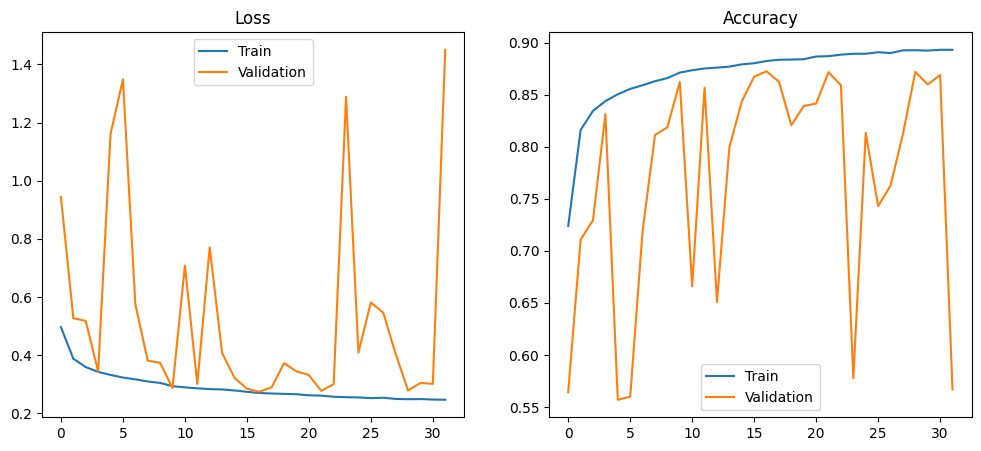

In [26]:
# Plot the learning curves

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dict["loss"], label="Train")
plt.plot(history_dict["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_dict["binary_accuracy"], label="Train")
plt.plot(history_dict["val_binary_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

file_path = base_path / "figures" / "pspnet" / "pspnet_loss_accuracy.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()